In [2]:
import numpy as np
from __future__ import print_function
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd

#
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [3]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
raw_data = pd.read_csv(url)
raw_data

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41197,2,1,16.94,2,1,132,164,1,70.0,0.5,6.94,1,5.00
41198,2,4,19.83,2,1,132,166,1,70.0,0.5,6.94,1,8.00
41199,2,1,17.31,2,1,132,137,1,70.0,0.5,6.94,1,8.00
41200,2,1,17.28,2,1,132,233,1,70.0,0.5,6.94,1,16.19


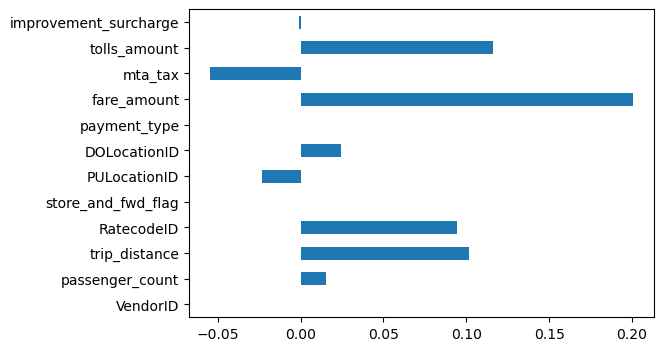

In [15]:
correlation_data = raw_data.corr()['tip_amount'].drop('tip_amount')
#correlation_data = raw_data.corr()['tip_amount'].drop('tip_amount')
correlation_data.plot(kind='barh' , figsize=(6, 4))
plt.show()

In [19]:
# get values of tip in floating numpy array
y = raw_data[['tip_amount']].values.astype('float32')

# remove target variable
prod_data = raw_data.drop(['tip_amount'], axis = 1)

# create numpy array of variables
X = prod_data.values

# finding the distribution of variables
X = normalize(X, axis = 1, norm='l1', copy= False)

In [22]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state=42)

In [26]:
#import RegressionTree from scikit Learn
from sklearn.tree import DecisionTreeRegressor

#create the RegressionTree model
dt_reg = DecisionTreeRegressor(criterion = 'squared_error' , max_depth = 8 , random_state = 35 )


In [27]:
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=35)

In [31]:
#inter the test values to check
y_prep = dt_reg.predict(X_test)

#trying to know less error or more
mean_squared = mean_squared_error(y_test, y_prep)

#decisionTree predicted scores 
# evaluate mean squared error on the test dataset
mse_score = mean_squared_error(y_test, y_prep)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = dt_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))


MSE score : 24.555
R^2 score : 0.028
